<a href="https://colab.research.google.com/github/Anthea05/PCVK26_03_Anthea/blob/main/P2_PERTANYAAN_PRAKTIKUM_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

PERTANYAAN PRAKTIKUM
Jawab pertanyaan berikut pada sel Markdown di dalam notebook Anda. Setiap
jawaban yang menyebut nilai atau ukuran wajib disertai keluaran program.
1. Tampilkan satu citra bebas menggunakan cv2_imshow() dan plt.imshow()
tanpa konversi warna apa pun. Mengapa hasilnya berbeda? Buktikan dengan
mencetak nilai satu piksel yang sama dari kedua cara pembacaan tersebut.
Fungsi cv2_imshow() dari Colab dirancang dengan asumsi format masukan BGR, sehingga menampilkan warna asli. Sebaliknya, fungsi plt.imshow() dari Matplotlib mengasumsikan array masukan memiliki urutan kanal RGB (Red, Green, Blue), akibatnya akan terbaca secara terbalik

In [1]:
from google.colab import files
uploaded = files.upload()

Saving KTM1d.jpeg to KTM1d.jpeg


--- Tampilan cv2_imshow (ASUMSI BGR) ---


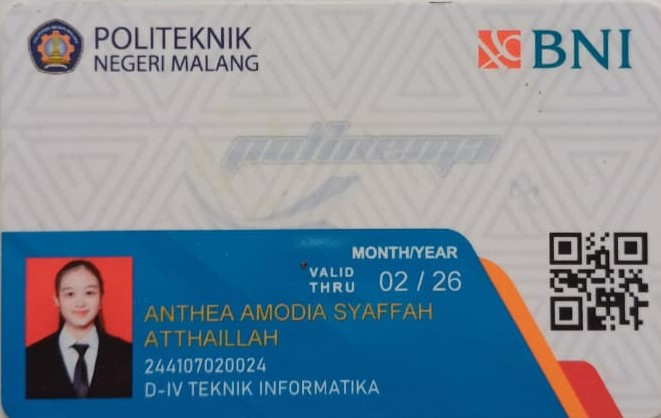

--- Tampilan plt.imshow (ASUMSI RGB) ---


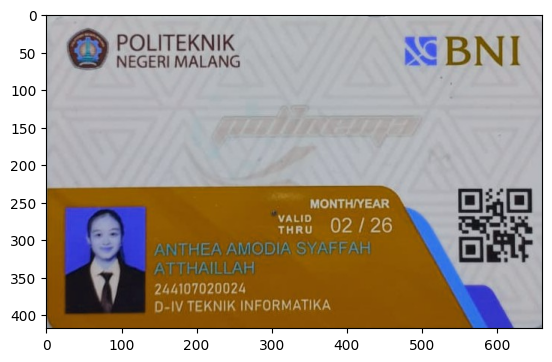

Kandungan nilai array piksel [0,0] (B, G, R): [180 184 185]


In [2]:
import cv2 as cv
from google.colab.patches import cv2_imshow
import matplotlib.pyplot as plt

img = cv.imread('KTM1d.jpeg')

print ("--- Tampilan cv2_imshow (ASUMSI BGR) ---")
cv2_imshow(img)

print ("--- Tampilan plt.imshow (ASUMSI RGB) ---")
plt.imshow(img)
plt.show()

print ("Kandungan nilai array piksel [0,0] (B, G, R):", img[0, 0])

2. Buat kanvas hitam berukuran sama dengan tipe data int16 dan int32.
Bandingkan dtype, min(), max(), dan nbytes keduanya. Apakah tampilannya
berbeda? Apakah ukuran memorinya berbeda? Jelaskan alasannya.


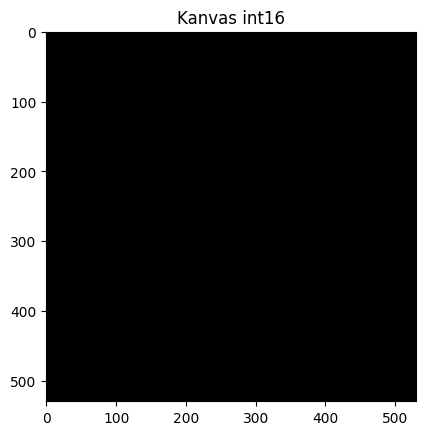

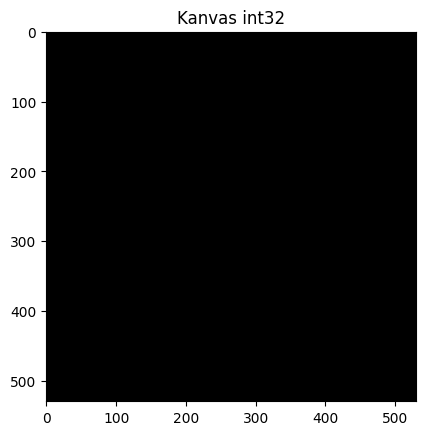

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

kanvas_int16 = np.zeros((530, 530, 3), dtype=np.int16)
kanvas_int32 = np.zeros((530, 530, 3), dtype=np.int32)

plt.figure()
plt.title("Kanvas int16")
plt.imshow(kanvas_int16)

plt.figure()
plt.title("Kanvas int32")
plt.imshow(kanvas_int32)

plt.show()

3. Apa kegunaan baris from google.colab.patches import cv2_imshow, dan
mengapa cv2.imshow() bawaan OpenCV tidak dapat dipakai di Google Colab?
Fungsi cv2.imshow() bawaan asli OpenCV dirancang untuk memanggil dan membuka sebuah jendela Graphical User Interface (GUI) baru. karena collab berjalan di lingkungan cloud web browser, maka perintah tersebut menyebabkan error. olerh karena itu google.colab.patches nama pengganti cv2_imshow yang bisa merender ke output sel halama collab

In [ ]:
4. Citra yang dibaca dengan skimage.io.imread() ditampilkan berdampingan
dengan hasil cv2.cvtColor(img, cv2.COLOR_BGR2RGB) atas citra yang
sama. Manakah yang menampilkan warna sebenarnya, dan manakah yang
kanalnya tertukar? Buktikan dengan nilai piksel, bukan dengan pengamatan
visual saja!

skimage.io.imread() vs cv2.cvtColor()

In [ ]:
5. Setelah citra ditampilkan dengan figsize yang jauh lebih besar, apakah nilai
img.shape ikut berubah? Jelaskan perbedaan antara mengubah ukuran citra
dan mengubah ukuran tampilan.
jika menggunakan skimage.io.imread(), pustaka ini otomatis membalik array dalam urutan RGB. oleh sebab itu hasil skimage akan menampilkan warna aslnya secara akurat menggunakan plt.imshow()

namun apabila menggunakan cv2.imread() (yang menghasilkan BGR) lalu mengaplikasikan cv2.cvtColor(img, cv2.COLOR_BGR2RGB), hasilnya juga akan menampilkan warna sebenarnya karena konversi tersebut meralat BGR menjadi RGB.

TUGAS PRAKTIKUM - Penerapan
Berdasarkan praktikum bagian 1 dan 2 kerjakan beberapa tugas berikut :
1. Tampilkan citra hanya pada kombinasi kanal Merah-Biru dan kanal Hijau-
Biru saja, dengan kanal yang tidak dipakai dinolkan. Susun keduanya
berdampingan dalam satu figure yang diberi judul.


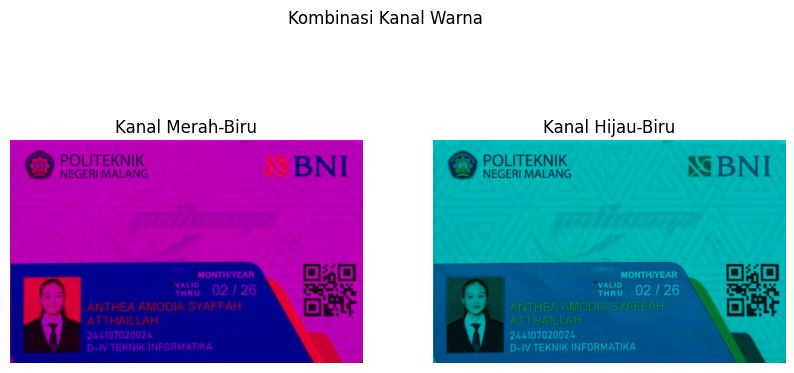

In [3]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

img = cv.imread('KTM1d.jpeg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

R = img[:,:,0].copy()
G = img[:,:,1].copy()
B = img[:,:,2].copy()


img_RB = img.copy()
img_RB[:,:,1] = 0


img_GB = img.copy()
img_GB[:,:,0] = 0

fig, axes = plt.subplots(1, 2, figsize=(10,5))
fig.suptitle('Kombinasi Kanal Warna')

axes[0].imshow(img_RB)
axes[0].set_title('Kanal Merah-Biru')
axes[0].axis('off')

axes[1].imshow(img_GB)
axes[1].set_title('Kanal Hijau-Biru')
axes[1].axis('off')

plt.show()

2. Tampilkan citra dalam tiga bentuk pencerminan: vertikal, horizontal, dan
keduanya, dalam satu figure berisi tiga subplot yang masing-masing diberi
label.

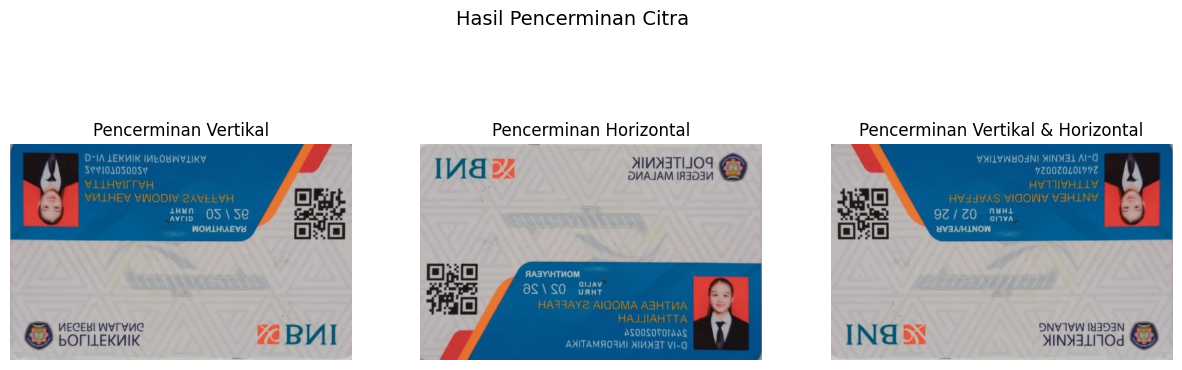

In [4]:
import cv2 as cv
import matplotlib.pyplot as plt

img = cv.imread('KTM1d.jpeg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

flip_vertikal = cv.flip(img, 0)
flip_horizontal = cv.flip(img, 1)
flip_keduanya = cv.flip(img, -1)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Hasil Pencerminan Citra', fontsize=14)

axes[0].imshow(flip_vertikal)
axes[0].set_title('Pencerminan Vertikal')
axes[0].axis('off')

axes[1].imshow(flip_horizontal)
axes[1].set_title('Pencerminan Horizontal')
axes[1].axis('off')

axes[2].imshow(flip_keduanya)
axes[2].set_title('Pencerminan Vertikal & Horizontal')
axes[2].axis('off')

plt.show()

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving DSC07874.JPG to DSC07874 (1).JPG


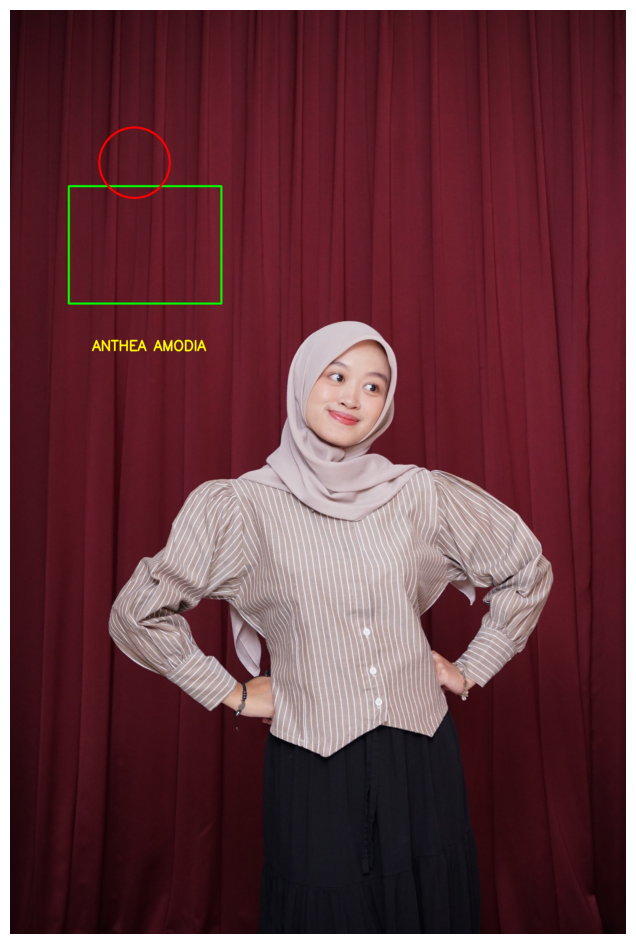

In [ ]:
import cv2 as cv
import matplotlib.pyplot as plt

# Membaca foto
img = cv.imread("/content/DSC07874.JPG")

if img is None:
    print("Foto tidak berhasil dibaca!")
else:

    img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)

    cv.rectangle(
        img_rgb,
        (250, 750),
        (900, 1250),
        (0, 255, 0),
        8
    )

    cv.circle(
        img_rgb,
        (530, 650),
        150,
        (255, 0, 0),
        8
    )


    cv.putText(
        img_rgb,
        "ANTHEA AMODIA",
        (350, 1450),
        cv.FONT_HERSHEY_SIMPLEX,
        2,
        (255, 255, 0),
        5,
        cv.LINE_AA
    )

    plt.figure(figsize=(8, 12))
    plt.imshow(img_rgb)
    plt.axis("off")
    plt.show()

TUGAS PRAKTIKUM - Analisa
1. Rumuskan satu pertanyaan tentang citra digital yang dapat Anda jawab
menggunakan kode dari modul ini. Contoh pertanyaan: berapa persen
piksel pada foto KTM Anda yang lebih gelap dari nilai 100? apakah
mengecilkan lalu membesarkan citra mengubah rata-rata intensitasnya?
Tuliskan pertanyaan Anda, rancangan program, data hasilnya, dan
kesimpulan Anda.

Pertanyaan
Apakah operasi pencerminan citra (flipping) mengubah dimensi gambar (shape) dan total rata-rata intensitas warnanya?


In [ ]:
import cv2 as cv
import numpy as np

img_asli = cv.imread('/content/DSC07874.JPG')

img_flip = cv.flip(img_asli, 1)

shape_asli = img_asli.shape
shape_flip = img_flip.shape

rata_asli = np.mean(img_asli)
rata_flip = np.mean(img_flip)

print(f"Dimensi citra ASLI   : {shape_asli}")
print(f"Dimensi citra FLIP   : {shape_flip}")
print(f"Rata-rata warna ASLI : {rata_asli}")
print(f"Rata-rata warna FLIP : {rata_flip}")

Dimensi citra ASLI   : (3936, 2624, 3)
Dimensi citra FLIP   : (3936, 2624, 3)
Rata-rata warna ASLI : 65.65374081725288
Rata-rata warna FLIP : 65.65374081725288


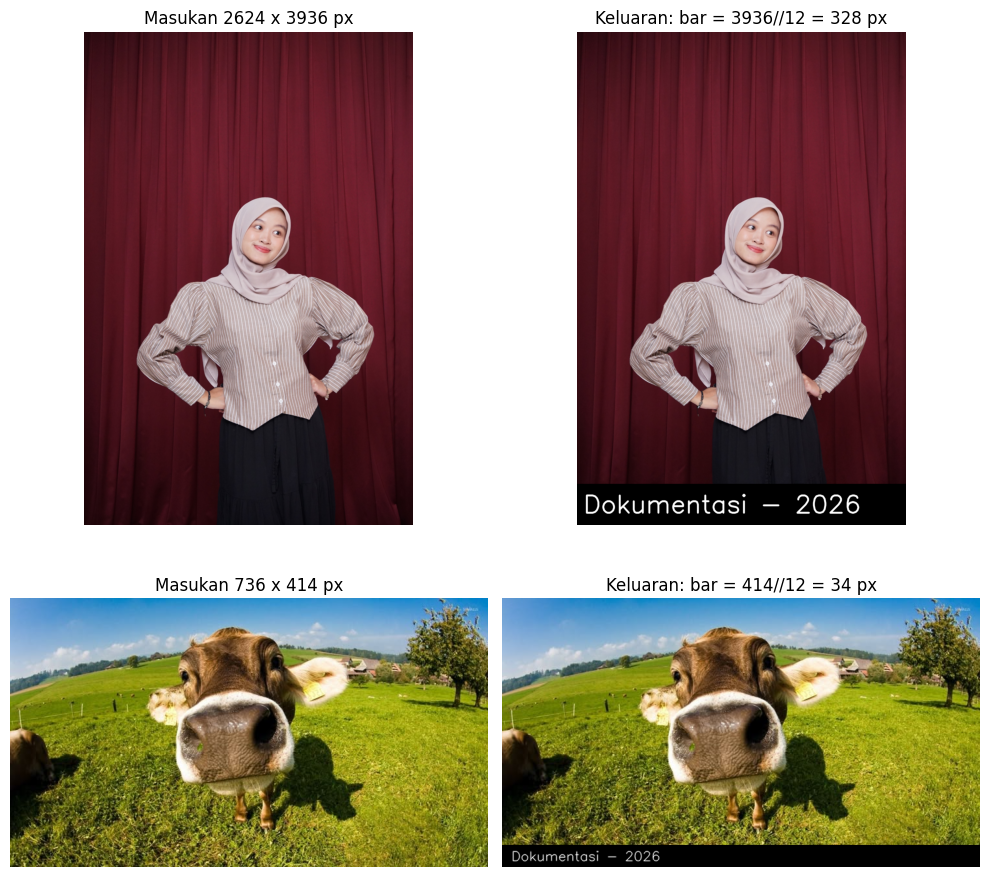

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

def tambah_label(img, teks):
    h, w = img.shape[:2]
    hasil = img.copy()

    tinggi_bar = h // 12

    hasil[h - tinggi_bar:h, :] = (0, 0, 0)

    font = cv.FONT_HERSHEY_SIMPLEX
    skala_font = tinggi_bar / 50
    tebal_font = max(1, tinggi_bar // 25)

    posisi_x = int(0.02 * w)
    posisi_y = h - int(tinggi_bar * 0.3)

    cv.putText(hasil, teks, (posisi_x, posisi_y), font, skala_font,
               (255, 255, 255), tebal_font, cv.LINE_AA)

    return hasil

img1 = cv.imread('/content/DSC07874.JPG')
img2 = cv.imread('/content/Cute Cow Wallpaper.jpg')

img1_rgb = cv.cvtColor(img1, cv.COLOR_BGR2RGB)
img2_rgb = cv.cvtColor(img2, cv.COLOR_BGR2RGB)

hasil1 = tambah_label(img1_rgb, 'Dokumentasi - 2026')
hasil2 = tambah_label(img2_rgb, 'Dokumentasi - 2026')

h1, w1 = img1.shape[:2]
h2, w2 = img2.shape[:2]

fig, axes = plt.subplots(2, 2, figsize=(10,10))

axes[0,0].imshow(img1_rgb)
axes[0,0].set_title(f'Masukan {w1} x {h1} px')
axes[0,0].axis('off')

axes[0,1].imshow(hasil1)
axes[0,1].set_title(f'Keluaran: bar = {h1}//12 = {h1//12} px')
axes[0,1].axis('off')

axes[1,0].imshow(img2_rgb)
axes[1,0].set_title(f'Masukan {w2} x {h2} px')
axes[1,0].axis('off')

axes[1,1].imshow(hasil2)
axes[1,1].set_title(f'Keluaran: bar = {h2}//12 = {h2//12} px')
axes[1,1].axis('off')

plt.tight_layout()
plt.show()

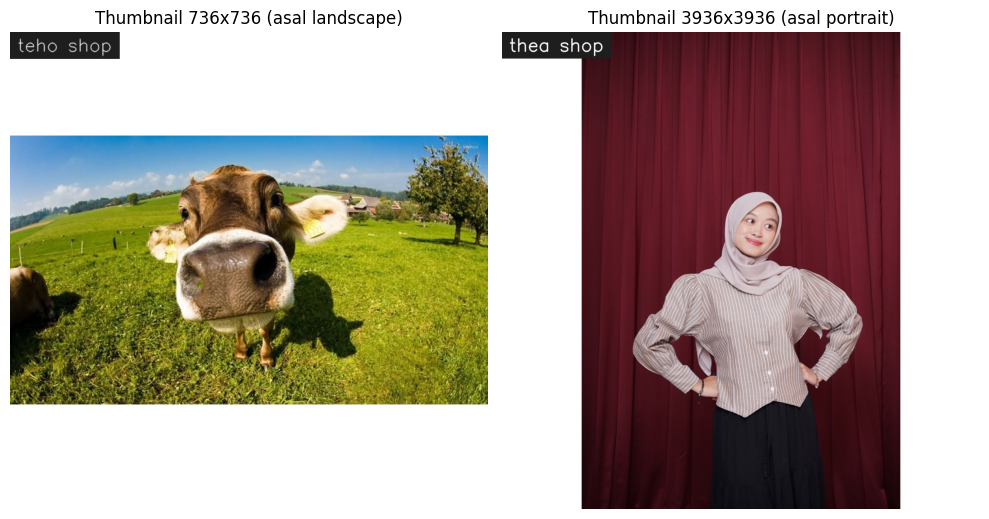

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

def buat_thumbnail(img, nama_toko, warna_latar=(255, 255, 255)):
    h, w = img.shape[:2]
    sisi = max(h, w)

    canvas = np.full((sisi, sisi, 3), warna_latar, dtype=np.uint8)

    y_offset = (sisi - h)
    x_offset = (sisi - w)

    canvas[y_offset:y_offset+h, x_offset:x_offset+w] = img

    font = cv.FONT_HERSHEY_SIMPLEX
    skala_font = sisi / 800
    tebal_font = max(1, sisi // 400)

    (lebar_teks, tinggi_teks), _ = cv.getTextSize(nama_toko, font, skala_font, tebal_font)
    pad = int(0.015 * sisi)
    posisi_x = pad
    posisi_y = pad + tinggi_teks

    cv.rectangle(canvas, (0, 0), (lebar_teks + 2*pad, tinggi_teks + 2*pad), (30, 30, 30), thickness=-1)
    cv.putText(canvas, nama_toko, (posisi_x, posisi_y), font, skala_font,
               (255, 255, 255), tebal_font, cv.LINE_AA)

    return canvas

img1 = cv.imread('/content/Cute Cow Wallpaper.jpg')
img2 = cv.imread('/content/DSC07874.JPG')

img1 = cv.cvtColor(img1, cv.COLOR_BGR2RGB)
img2 = cv.cvtColor(img2, cv.COLOR_BGR2RGB)

hasil1 = buat_thumbnail(img1, 'teho shop')
hasil2 = buat_thumbnail(img2, 'thea shop')

fig, axes = plt.subplots(1, 2, figsize=(10,6))
axes[0].imshow(hasil1)
axes[0].set_title(f'Thumbnail {hasil1.shape[1]}x{hasil1.shape[0]} (asal landscape)')
axes[0].axis('off')

axes[1].imshow(hasil2)
axes[1].set_title(f'Thumbnail {hasil2.shape[1]}x{hasil2.shape[0]} (asal portrait)')
axes[1].axis('off')

plt.tight_layout()
plt.show()